# Bearing Autoencoder — Quotient Operator Experiment

**Goal:** train an autoencoder on *healthy signals only* (with Monte Carlo nuisance).
The reconstruction error then becomes an implicit membership function for M_healthy.

Architecture: `Conv1D encoder → dense latent → Conv1DTranspose decoder`

Steps:
1. Generate MC dataset (healthy train/val + all regimes for test)
2. Build and train the autoencoder
3. Verify reconstruction fidelity on healthy signals
4. Measure reconstruction error across all regimes — this is the anomaly score
5. Visualise latent space geometry (PCA of latent vectors)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from collections import deque

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

np.random.seed(42)
tf.random.set_seed(42)
print('TF version:', tf.__version__)

TF version: 2.16.2


## 1. Simulator

In [3]:
from bearing_simulator import BearingSignalSimulator

In [4]:
sim = BearingSignalSimulator()
SIG_LEN = len(sim.t)
print(f'Signal length: {SIG_LEN} samples')

Signal length: 1200 samples


## 2. Generate dataset

- **Train / Val:** healthy only (MC) — the autoencoder sees only M_healthy
- **Test:** all four regimes — used only for evaluation, never for training

In [5]:
REGIMES = ['healthy', 'outer_race', 'inner_race', 'ball_fault']
COLORS  = ['#01696f', '#a12c7b', '#da7101', '#006494']
LABELS  = ['Healthy', 'Outer Race', 'Inner Race', 'Ball Fault']

N_TRAIN  = 800   # healthy train
N_VAL    = 200   # healthy val
N_TEST   = 150   # per regime for test

# ── Healthy train/val ────────────────────────────────────────────────────
X_healthy = np.array([sim.sample('healthy', mc=True) for _ in range(N_TRAIN + N_VAL)])

# Normalise — fit scaler on train only
scaler = StandardScaler()
X_healthy_sc = scaler.fit_transform(X_healthy)

X_train = X_healthy_sc[:N_TRAIN, :, np.newaxis].astype('float32')  # (N, L, 1)
X_val   = X_healthy_sc[N_TRAIN:, :, np.newaxis].astype('float32')

# ── Test set — all regimes ───────────────────────────────────────────────
X_test_list, y_test_list = [], []
for i, regime in enumerate(REGIMES):
    sigs = np.array([sim.sample(regime, mc=True) for _ in range(N_TEST)])
    sigs_sc = scaler.transform(sigs)
    X_test_list.append(sigs_sc)
    y_test_list.extend([i] * N_TEST)

X_test = np.concatenate(X_test_list, axis=0)[:, :, np.newaxis].astype('float32')
y_test = np.array(y_test_list)

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')

Train: (800, 1200, 1)  Val: (200, 1200, 1)  Test: (600, 1200, 1)


## 3. Autoencoder architecture

```
Encoder: Conv1D(32) → Conv1D(64) → Conv1D(128) → Flatten → Dense(latent_dim)
Decoder: Dense → Reshape → Conv1DTranspose(128) → Conv1DTranspose(64) → Conv1DTranspose(1)
```

The latent vector (dim=16) is the quotient representation.
All convolutional layers use ReLU; the final decoder layer uses linear activation
to reconstruct the full signal range without clipping.

In [6]:
LATENT_DIM = 16

def build_autoencoder(sig_len, latent_dim):
    # ── Encoder ──────────────────────────────────────────────────────────
    inp = keras.Input(shape=(sig_len, 1), name='signal_in')
    x = layers.Conv1D(32,  kernel_size=16, strides=2, padding='same', activation='relu')(inp)
    x = layers.Conv1D(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1D(128, kernel_size=4,  strides=2, padding='same', activation='relu')(x)
    conv_shape = x.shape[1:]            # remember shape before flatten
    x = layers.Flatten()(x)
    latent = layers.Dense(
        latent_dim,
        activity_regularizer=keras.regularizers.l1(1.5e-4),
        name='latent'
    )(x)


    # ── Decoder ──────────────────────────────────────────────────────────
    y = layers.Dense(conv_shape[0] * conv_shape[1], activation='relu')(latent)
    y = layers.Reshape(conv_shape)(y)
    y = layers.Conv1DTranspose(128, kernel_size=4,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(32,  kernel_size=16, strides=2, padding='same', activation='relu')(y)
    # Final layer: crop or pad to exact sig_len, linear activation
    y = layers.Conv1D(1, kernel_size=1, padding='same', activation='linear', name='signal_out')(y)
    y = layers.Cropping1D((0, y.shape[1] - sig_len))(y) if y.shape[1] > sig_len else y

    autoencoder = Model(inp, y, name='bearing_autoencoder')
    encoder     = Model(inp, latent, name='encoder')
    return autoencoder, encoder

ae, encoder = build_autoencoder(SIG_LEN, LATENT_DIM)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
ae.summary()

2026-07-15 19:33:27.315657: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-07-15 19:33:27.315691: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-15 19:33:27.315698: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-15 19:33:27.315715: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-15 19:33:27.315729: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "bearing_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_in (InputLayer)          │ (None, 1200, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 600, 32)        │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 300, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 150, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │       307,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19200)          │       326,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 300, 128)       │        65,664 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 600, 64)        │        65,600 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 1200, 32)       │        32,800 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ signal_out (Conv1D)             │ (None, 1200, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,601 (3.23 MB)

 Trainable params: 847,601 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training

Trained on healthy signals only.
Early stopping on validation loss — prevents overfitting to the training orbit.

Epoch 1/100


2026-07-15 19:33:28.144165: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.6728 - val_loss: 0.3340 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2045 - val_loss: 0.1231 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.1109 - val_loss: 0.0986 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0910 - val_loss: 0.0866 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.0827 - val_loss: 0.0814 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0770 - val_loss: 0.0753 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0723 - val_loss: 0.0729 - learning_rate: 0.0010
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0706 - val_loss: 0.0705 - learning_rate: 0.0010
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0695 - val_loss: 0.0698 - learning_rate: 0.0010
Epoch 10/100
25/25 ━━━

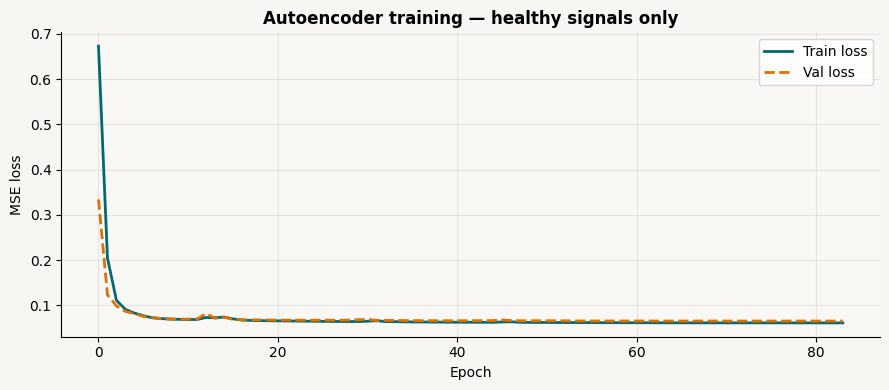

In [7]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
]

history = ae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Plot training curve
fig, ax = plt.subplots(figsize=(9, 4), facecolor='#f7f6f2')
ax.set_facecolor('#f9f8f5')
ax.plot(history.history['loss'],     label='Train loss', color='#01696f', lw=2)
ax.plot(history.history['val_loss'], label='Val loss',   color='#da7101', lw=2, ls='--')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Autoencoder training — healthy signals only', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.25); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Reconstruction fidelity on healthy signals

Verify the autoencoder faithfully reconstructs the canonical signal
and MC variants before using reconstruction error as anomaly score.

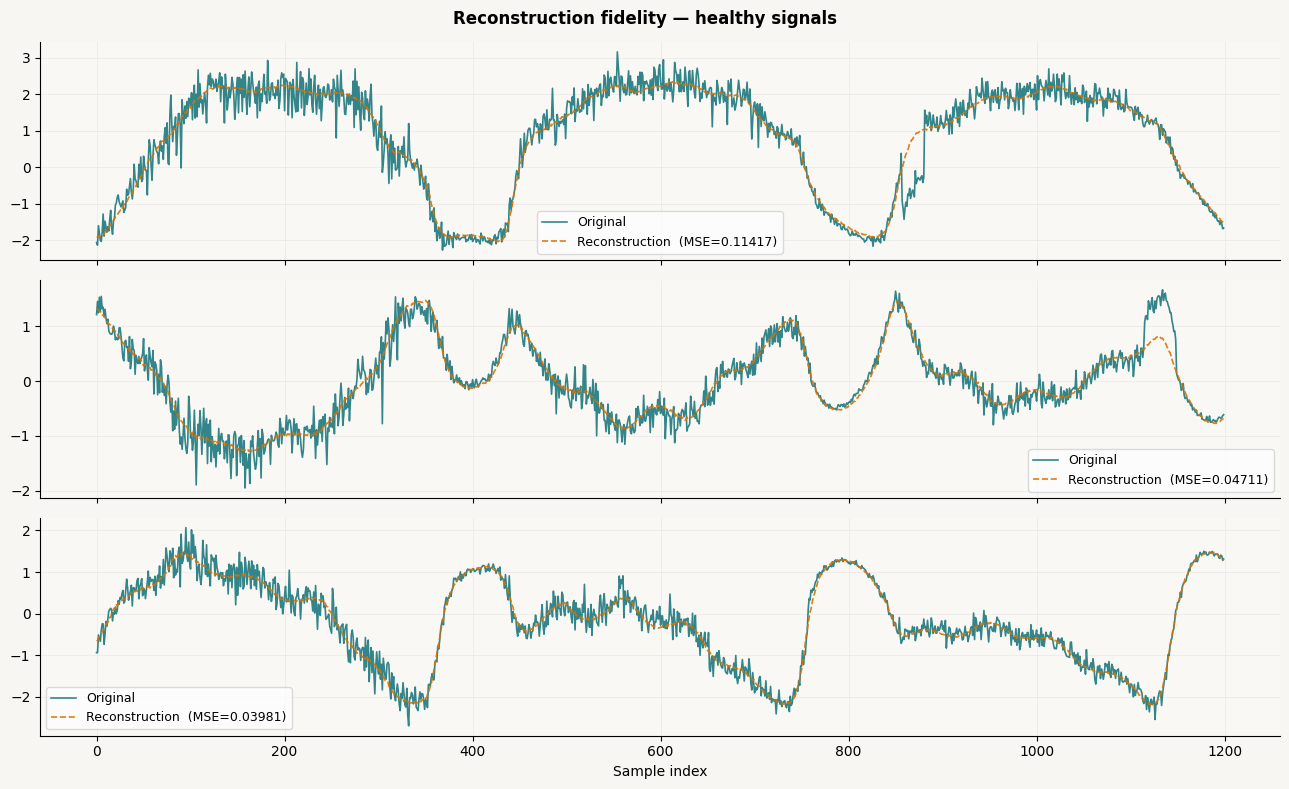

In [8]:
# Pick 3 healthy test samples
n_show = 3
samples = X_test[:n_show]          # first N_TEST entries are healthy
recons  = ae.predict(samples, verbose=0)

fig, axes = plt.subplots(n_show, 1, figsize=(13, 8), facecolor='#f7f6f2', sharex=True)
for i, ax in enumerate(axes):
    ax.set_facecolor('#f9f8f5')
    orig = samples[i, :, 0]
    rec  = recons[i, :, 0]
    err  = np.mean((orig - rec)**2)
    ax.plot(orig, color='#01696f', lw=1.2, alpha=0.8, label='Original')
    ax.plot(rec,  color='#da7101', lw=1.2, alpha=0.9, ls='--', label=f'Reconstruction  (MSE={err:.5f})')
    ax.legend(fontsize=9, framealpha=0.7)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(True, alpha=0.2, lw=0.5)
axes[-1].set_xlabel('Sample index')
fig.suptitle('Reconstruction fidelity — healthy signals', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Reconstruction error as anomaly score

The threshold τ is set at the p98 of healthy reconstruction errors.
Any signal with error > τ is considered outside M_healthy.

No geometric assumption about the shape of M_healthy is needed —
the autoencoder encodes it implicitly.

Threshold τ (p98 healthy MSE) = 0.115771


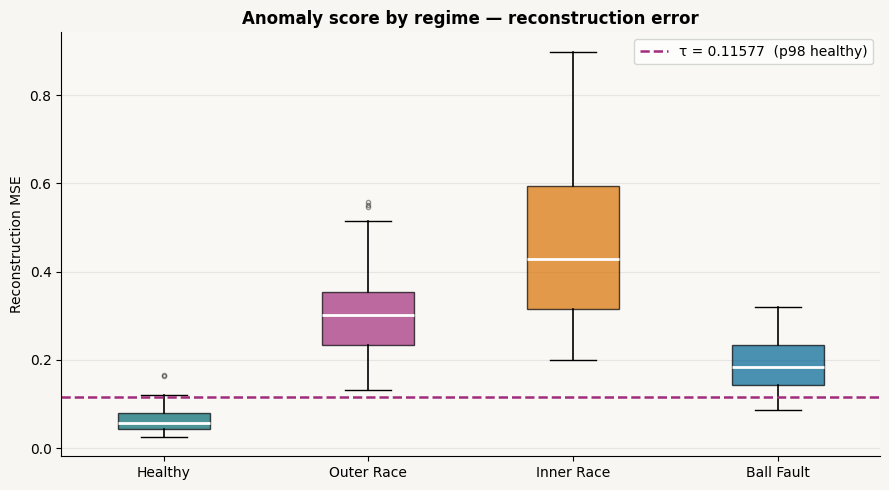


Detection rate (MSE > τ):
  Healthy     : 2.0%
  Outer Race  : 100.0%
  Inner Race  : 100.0%
  Ball Fault  : 92.0%


In [9]:
# Compute per-sample MSE for the full test set
X_test_rec = ae.predict(X_test, verbose=0)
mse = np.mean((X_test - X_test_rec)**2, axis=(1, 2))

# Calibrate threshold on healthy test samples
healthy_mse = mse[y_test == 0]
tau = np.percentile(healthy_mse, 98)
print(f'Threshold τ (p98 healthy MSE) = {tau:.6f}')

# ── Box plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5), facecolor='#f7f6f2')
ax.set_facecolor('#f9f8f5')

data_per_regime = [mse[y_test == i] for i in range(4)]
bp = ax.boxplot(data_per_regime, patch_artist=True,
                medianprops=dict(color='white', lw=2),
                whiskerprops=dict(lw=1.2),
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
for patch, color in zip(bp['boxes'], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.7)

ax.axhline(tau, color='#a12c7b', lw=1.8, ls='--', label=f'τ = {tau:.5f}  (p98 healthy)')
ax.set_xticks(range(1, 5)); ax.set_xticklabels(LABELS, fontsize=10)
ax.set_ylabel('Reconstruction MSE')
ax.set_title('Anomaly score by regime — reconstruction error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25, axis='y')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()

# ── Detection rate above τ ───────────────────────────────────────────────
print('\nDetection rate (MSE > τ):')
for i, label in enumerate(LABELS):
    rate = np.mean(mse[y_test == i] > tau)
    print(f'  {label:12s}: {rate:.1%}')

## 7. Latent space geometry

PCA of the 16-dimensional latent vectors for all test samples.

Expected result: healthy signals cluster in a compact region.
Fault regimes deviate — their latent vectors fall outside the healthy orbit.
This is the learned quotient space in action.

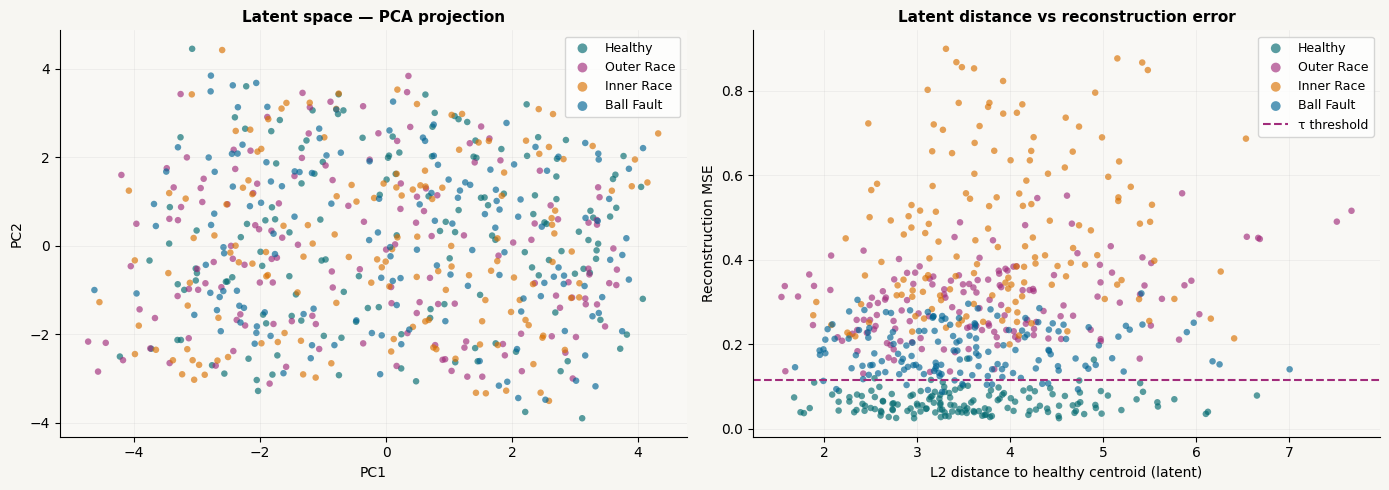

In [10]:
Z_latent = encoder.predict(X_test, verbose=0)   # (N_test_total, LATENT_DIM)
Z_pca    = PCA(n_components=2).fit_transform(Z_latent)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#f7f6f2')

# Left — PCA scatter
ax = axes[0]
ax.set_facecolor('#f9f8f5')
for i, (color, label) in enumerate(zip(COLORS, LABELS)):
    mask = y_test == i
    ax.scatter(Z_pca[mask, 0], Z_pca[mask, 1],
               c=color, s=22, alpha=0.65, label=label, edgecolors='none')
ax.set_title('Latent space — PCA projection', fontsize=11, fontweight='bold')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(fontsize=9, framealpha=0.8, markerscale=1.5)
ax.spines[['top','right']].set_visible(False)
ax.grid(True, alpha=0.2, lw=0.5)

# Right — MSE vs distance to healthy centroid in latent space
ax2 = axes[1]
ax2.set_facecolor('#f9f8f5')
mu_healthy = Z_latent[y_test == 0].mean(axis=0)
dist_to_healthy = np.linalg.norm(Z_latent - mu_healthy, axis=1)
for i, (color, label) in enumerate(zip(COLORS, LABELS)):
    mask = y_test == i
    ax2.scatter(dist_to_healthy[mask], mse[mask],
                c=color, s=22, alpha=0.65, label=label, edgecolors='none')
ax2.axhline(tau, color='#a12c7b', lw=1.5, ls='--', label=f'τ threshold')
ax2.set_xlabel('L2 distance to healthy centroid (latent)')
ax2.set_ylabel('Reconstruction MSE')
ax2.set_title('Latent distance vs reconstruction error', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9, framealpha=0.8, markerscale=1.5)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(True, alpha=0.2, lw=0.5)

plt.tight_layout(); plt.show()

## 8. Summary

| What we did | Why it matters for the paper |
|---|---|
| Trained autoencoder on healthy MC orbit only | The model learns M_healthy without fault labels |
| Used reconstruction error as membership function | No geometric assumption about the shape of M_healthy |
| Calibrated threshold τ at p98 healthy MSE | Principled, data-driven boundary |
| Visualised latent space | Confirms the latent is a quotient space: healthy collapses, faults separate |

**Next step:** test whether the same latent, trained on simulation, separates regimes
on real CWRU bearing data — the transfer experiment.

In [11]:
data_root = Path("CWRU_Bearing_NumPy-main/Data")

def load_1797_normal(bearing_id):

    bearing_rpm = f"{bearing_id} RPM"
    bearing_normal = f"{bearing_id}_Normal.npz"
    d = np.load(data_root / bearing_rpm / bearing_normal)
    return d["DE"]  # Drive End

def load_1797_ball(bearing_id):
    bearing_rpm = f"{bearing_id} RPM"
    folder = data_root / bearing_rpm
    signals = []
    bearing_pattern = f"{bearing_id}_B_*_DE12.npz"
    for f in sorted(folder.glob(bearing_pattern)):
        d = np.load(f)
        signals.append(d["DE"])
    return np.concatenate(signals)

def load_1797_inner(bearing_id):
    bearing_rpm = f"{bearing_id} RPM"
    folder = data_root / bearing_rpm
    signals = []
    bearing_pattern = f"{bearing_id}_IR_*_DE12.npz"
    for f in sorted(folder.glob(bearing_pattern)):
        d = np.load(f)
        signals.append(d["DE"])
    return np.concatenate(signals)

def load_1797_outer(bearing_id):
    bearing_rpm = f"{bearing_id} RPM"
    folder = data_root / bearing_rpm
    signals = []
    bearing_pattern = f"{bearing_id}_OR*@*_DE12.npz"
    for f in sorted(folder.glob(bearing_pattern)):
        d = np.load(f)
        signals.append(d["DE"])
    return np.concatenate(signals)

In [12]:
def make_windows(x, win=1200, step=1200):
    n = (len(x) - win) // step + 1
    return np.stack([x[i*step:i*step+win] for i in range(n)], axis=0)

# ── Compute CWRU MSEs first ─────────────────────────────────────────────
def cwru_mse(signal_1d):
    ws    = make_windows(signal_1d, win=1200, step=1200)
    ws_2d = ws.reshape(ws.shape[0], -1)
    ws_sc = scaler.transform(ws_2d)
    X     = ws_sc[:, :, np.newaxis].astype('float32')
    X_rec = ae.predict(X, verbose=0)
    return np.mean((X - X_rec)**2, axis=(1, 2))


#### FIELD DATA EXPERIMENT ####

In [13]:
mu_mc  = healthy_mse.mean()
std_mc = healthy_mse.std()
z_mc   = (tau - mu_mc) / std_mc

print(f"mu_mc  = {mu_mc:.6f}")
print(f"std_mc = {std_mc:.6f}")
print(f"z_mc   = {z_mc:.4f}")


mu_mc  = 0.062283
std_mc = 0.025692
z_mc   = 2.0819


##### ADAPTIVE TAU

In [14]:
class AdaptiveTau:
    def __init__(self, z_mc, window_size=500):
        self.z_mc       = z_mc
        self.window_size = window_size
        self.buf        = deque(maxlen=window_size)

    def update(self, mse_value):
        self.buf.append(float(mse_value))
        arr    = np.array(self.buf)
        mu     = arr.mean()
        sigma  = arr.std() if len(arr) > 1 else 0.0
        tau    = mu + self.z_mc * sigma
        return mu, sigma, tau

    # ── nuevo método ──────────────────────────────────────────
    def warmup_trace(self, mse_sequence):
        """
        Pasa la secuencia completa por la ventana deslizante
        y devuelve los tres historiales listos para graficar.

        Returns
        -------
        history_mu    : list[float]
        history_sigma : list[float]
        history_tau   : list[float]
        """
        history_mu, history_sigma, history_tau = [], [], []
        for val in mse_sequence:
            mu, sigma, tau = self.update(val)
            history_mu.append(mu)
            history_sigma.append(sigma)
            history_tau.append(tau)
        return history_mu, history_sigma, history_tau



In [15]:
def run_experiment(bearing_id):

    normal_1797 = load_1797_normal(bearing_id)
    ball_1797   = load_1797_ball(bearing_id)
    inner_1797  = load_1797_inner(bearing_id)
    outer_1797  = load_1797_outer(bearing_id)

    print("Normal:", normal_1797.shape)
    print("Ball:  ", ball_1797.shape)
    print("Inner: ", inner_1797.shape)
    print("Outer: ", outer_1797.shape)

    # ── Helper local ──────────────────────────────────────────────────────────
    def cwru_mse(signal):
        ws    = make_windows(signal, win=1200, step=1200)
        ws_2d = ws.reshape(ws.shape[0], -1)
        ws_sc = scaler.transform(ws_2d)
        X     = ws_sc[:, :, np.newaxis].astype('float32')
        x_rec = ae.predict(X, verbose=0)
        return np.mean((X - x_rec)**2, axis=(1, 2))

    # ── τ_MC (espacio simulación) ─────────────────────────────────────────────
    X_healthy_rec  = ae.predict(X_train, verbose=0)
    mse_mc_healthy = np.mean((X_train - X_healthy_rec)**2, axis=(1, 2))
    tau_mc         = np.percentile(mse_mc_healthy, 95)

    # z_mc: cuántas sigmas sobre la media MC equivale τ_MC
    mu_mc  = mse_mc_healthy.mean()
    std_mc = mse_mc_healthy.std()
    z_mc   = (tau_mc - mu_mc) / std_mc          # ← AÑADIDO

    print(f"τ_MC = {tau_mc:.6f}  (z_mc = {z_mc:.3f})")

    # ── MSE campo para cada régimen ───────────────────────────────────────────
    mse_cwru_healthy = cwru_mse(normal_1797)     # ← ahora cwru_mse existe
    mse_cwru_ball    = cwru_mse(ball_1797)
    mse_cwru_inner   = cwru_mse(inner_1797)
    mse_cwru_outer   = cwru_mse(outer_1797)

    print(f"Windows → healthy:{len(mse_cwru_healthy)} ball:{len(mse_cwru_ball)} "
          f"inner:{len(mse_cwru_inner)} outer:{len(mse_cwru_outer)}")

    # ── Blueprint learning ────────────────────────────────────────────────────
    mu_cwru  = mse_cwru_healthy.mean()
    std_cwru = mse_cwru_healthy.std()

    tau_bridge    = mu_cwru + z_mc * std_cwru
    tau_campo_p98 = np.percentile(mse_cwru_healthy, 98)

    print(f"Campo    → mu={mu_cwru:.4f}, std={std_cwru:.4f}")
    print(f"τ_bridge = {tau_bridge:.4f}")
    print(f"τ_campo p98 = {tau_campo_p98:.4f}")

    # ── Ventana adaptativa (warm-up con healthy CWRU) ─────────────────────────
    adaptive = AdaptiveTau(z_mc=z_mc, window_size=500)
    for mse_val in mse_cwru_healthy:
        mu_t, sigma_t, tau_t = adaptive.update(mse_val)

    print(f"\nτ_adaptativo (tras warm-up) = {tau_t:.4f}")
    print(f"  mu_t={mu_t:.4f}, sigma_t={sigma_t:.4f}")

    # ── Detection rates ───────────────────────────────────────────────────────
    def detection_rate(mse, tau):
        return np.mean(mse > tau) * 100.0

    print("\n── Detection rates (MSE > τ) ──────────────────────────────")
    print(f"{'Régimen':<12} {'τ_MC':>8} {'τ_bridge':>10} {'τ_p98_campo':>13} {'τ_adapt':>10}")
    print("-" * 55)

    for name, mse in [("Healthy",  mse_cwru_healthy),
                      ("Ball",     mse_cwru_ball),
                      ("Inner",    mse_cwru_inner),
                      ("Outer",    mse_cwru_outer)]:
        dr_mc     = detection_rate(mse, tau_mc)
        dr_bridge = detection_rate(mse, tau_bridge)
        dr_p98    = detection_rate(mse, tau_campo_p98)
        dr_adapt  = detection_rate(mse, tau_t)
        print(f"{name:<12} {dr_mc:>7.1f}% {dr_bridge:>9.1f}% {dr_p98:>12.1f}% {dr_adapt:>9.1f}%")

    return (mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer,
            tau_mc, tau_bridge, tau_campo_p98, tau_t)


In [ ]:
def plot_experiment(ID, mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer, tau_mc, tau_bridge, tau_campo_p98, tau_t):
    mse_mean = mse_cwru_healthy.mean()
    mse_std  = mse_cwru_healthy.std()
    p98      = np.percentile(mse_cwru_healthy, 98)
    p99      = np.percentile(mse_cwru_healthy, 99)

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.hist(mse_cwru_healthy, bins=50, density=True, alpha=0.6, color='steelblue', label='Healthy CWRU')

    ax.axvline(tau_mc,          color='red',    linestyle='--', lw=1.5, label=f'τ_MC       = {tau_mc:.4f}')
    ax.axvline(tau_bridge,      color='orange', linestyle='--', lw=1.5, label=f'τ_bridge   = {tau_bridge:.4f}')
    ax.axvline(tau_campo_p98,   color='green',  linestyle='--', lw=1.5, label=f'τ_p98_field= {tau_campo_p98:.4f}')
    ax.axvline(tau_t,           color='purple', linestyle='--', lw=1.5, label=f'τ_adaptive = {tau_t:.4f}')

    ax.set_xlabel("MSE")
    ax.set_ylabel("Density")
    ax.set_title(f"MSE Distribution — Healthy CWRU in Q ({ID})")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"Healthy CWRU → mean={mse_mean:.4f}, std={mse_std:.4f}, p98={p98:.4f}, p99={p99:.4f}")
    adaptive_plot = AdaptiveTau(z_mc=z_mc, window_size=500)
    history_mu, history_sigma, history_tau = adaptive_plot.warmup_trace(mse_cwru_healthy)

    steps = range(len(history_tau))

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    # ── τ ─────────────────────────────────────────────────────────
    axes[0].plot(steps, history_tau, color='purple', lw=1.5, label='τ_adaptive')
    axes[0].axhline(tau_bridge,    color='orange', linestyle='--', lw=1.2,
                    label=f'τ_bridge = {tau_bridge:.4f}')
    axes[0].axhline(tau_campo_p98, color='green',  linestyle='--', lw=1.2,
                    label=f'τ_p98    = {tau_campo_p98:.4f}')
    axes[0].axvline(500, color='gray', linestyle=':', lw=1, label='window full')
    axes[0].set_ylabel("τ")
    axes[0].set_title(f"Adaptive τ convergence — Healthy CWRU cold start ({ID})")
    axes[0].legend(fontsize=8)

    # ── μ ─────────────────────────────────────────────────────────
    axes[1].plot(steps, history_mu, color='steelblue', lw=1.5)
    axes[1].axhline(mu_cwru, color='steelblue', linestyle='--', lw=1.2,
                    label=f'final μ = {mu_cwru:.4f}')
    axes[1].set_ylabel("μ (mean MSE)")
    axes[1].legend(fontsize=8)

    # ── σ ─────────────────────────────────────────────────────────
    axes[2].plot(steps, history_sigma, color='coral', lw=1.5)
    axes[2].axhline(std_cwru, color='coral', linestyle='--', lw=1.2,
                    label=f'final σ = {std_cwru:.4f}')
    axes[2].set_ylabel("σ (std MSE)")
    axes[2].set_xlabel("Window (samples)")
    axes[2].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    

#### 1730 ####

Normal: (485643, 1)
Ball:   (486812, 1)
Inner:  (488144, 1)
Outer:  (854807, 1)
τ_MC = 0.094570  (z_mc = 1.679)
Windows → healthy:404 ball:405 inner:406 outer:712
Campo    → mu=0.2586, std=0.0191
τ_bridge = 0.2906
τ_campo p98 = 0.3009

τ_adaptativo (tras warm-up) = 0.2906
  mu_t=0.2586, sigma_t=0.0191

── Detection rates (MSE > τ) ──────────────────────────────
Régimen          τ_MC   τ_bridge   τ_p98_campo    τ_adapt
-------------------------------------------------------
Healthy        100.0%       5.4%          2.2%       5.4%
Ball           100.0%     100.0%         99.8%     100.0%
Inner          100.0%     100.0%        100.0%     100.0%
Outer          100.0%     100.0%        100.0%     100.0%


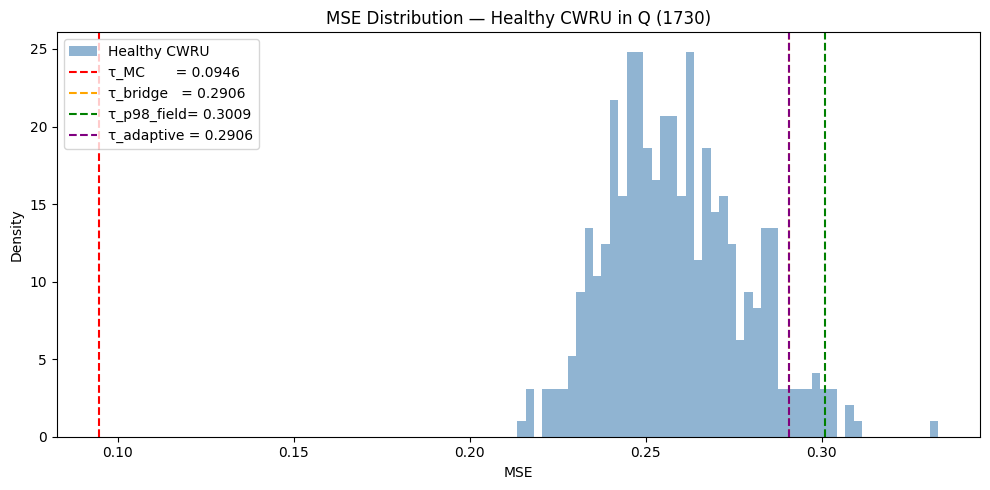

Healthy CWRU → mean=0.2586, std=0.0191, p98=0.3009, p99=0.3033


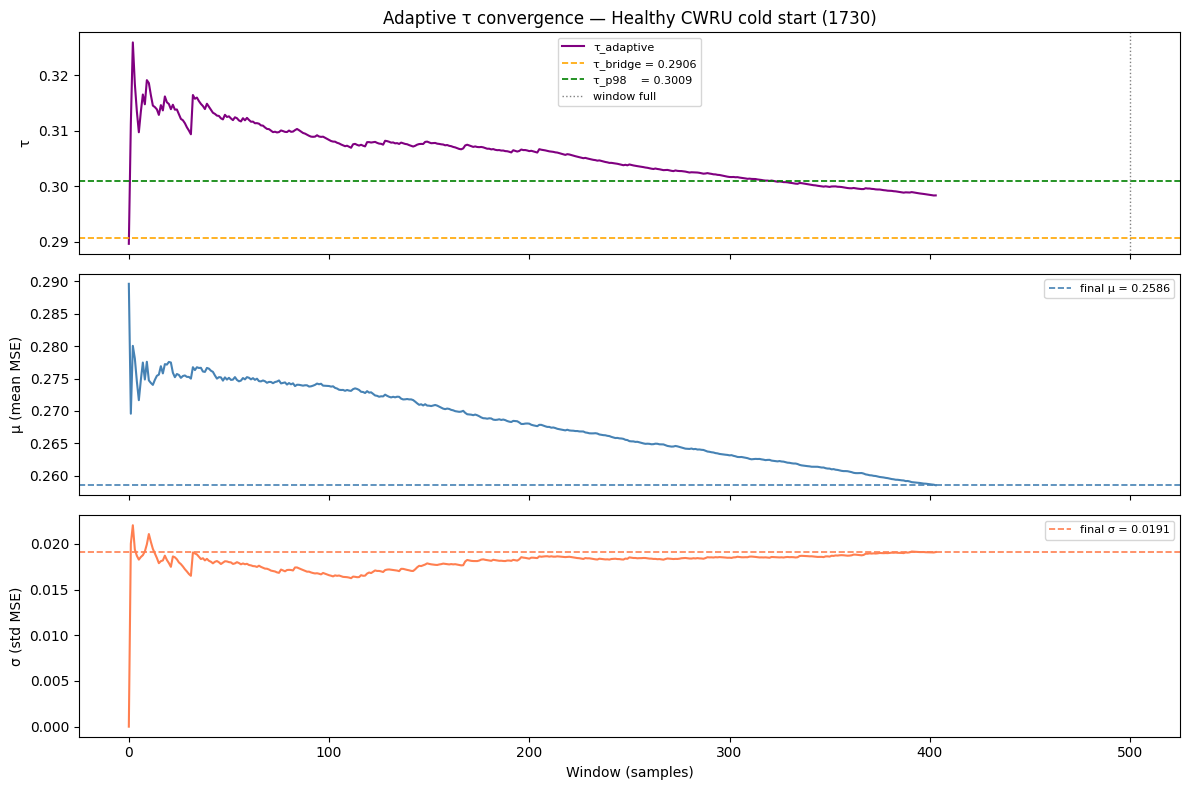

In [17]:
mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer, tau_mc, tau_bridge, tau_campo_p98, tau_t = run_experiment(bearing_id="1730")
mu_cwru  = mse_cwru_healthy.mean()
std_cwru = mse_cwru_healthy.std()

plot_experiment("1730", mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer, tau_mc, tau_bridge, tau_campo_p98, tau_t)

#### 1750 ####

Normal: (485063, 1)
Ball:   (486667, 1)
Inner:  (487179, 1)
Outer:  (854371, 1)
τ_MC = 0.094570  (z_mc = 1.679)
Windows → healthy:404 ball:405 inner:405 outer:711
Campo    → mu=0.2598, std=0.0173
τ_bridge = 0.2888
τ_campo p98 = 0.3008

τ_adaptativo (tras warm-up) = 0.2888
  mu_t=0.2598, sigma_t=0.0173

── Detection rates (MSE > τ) ──────────────────────────────
Régimen          τ_MC   τ_bridge   τ_p98_campo    τ_adapt
-------------------------------------------------------
Healthy        100.0%       4.7%          2.2%       4.7%
Ball           100.0%     100.0%         99.8%     100.0%
Inner          100.0%     100.0%        100.0%     100.0%
Outer          100.0%     100.0%        100.0%     100.0%


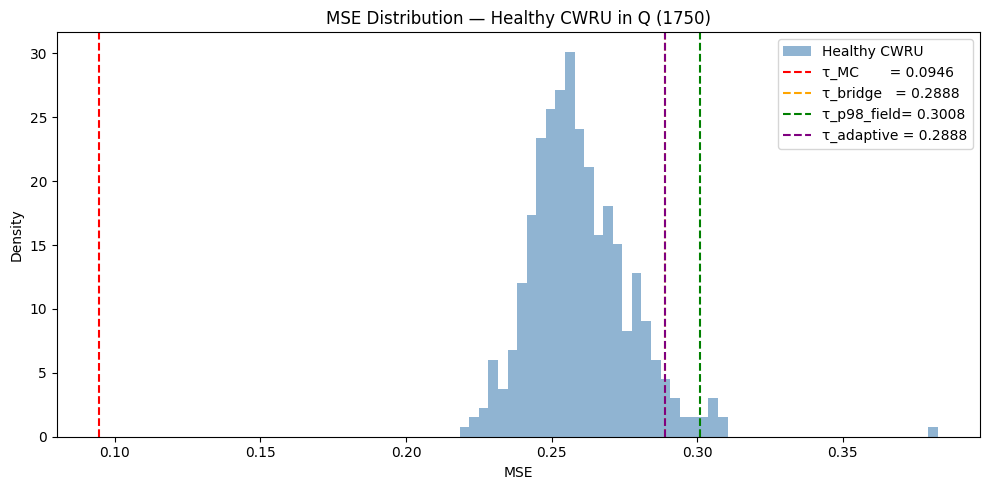

Healthy CWRU → mean=0.2598, std=0.0173, p98=0.3008, p99=0.3061


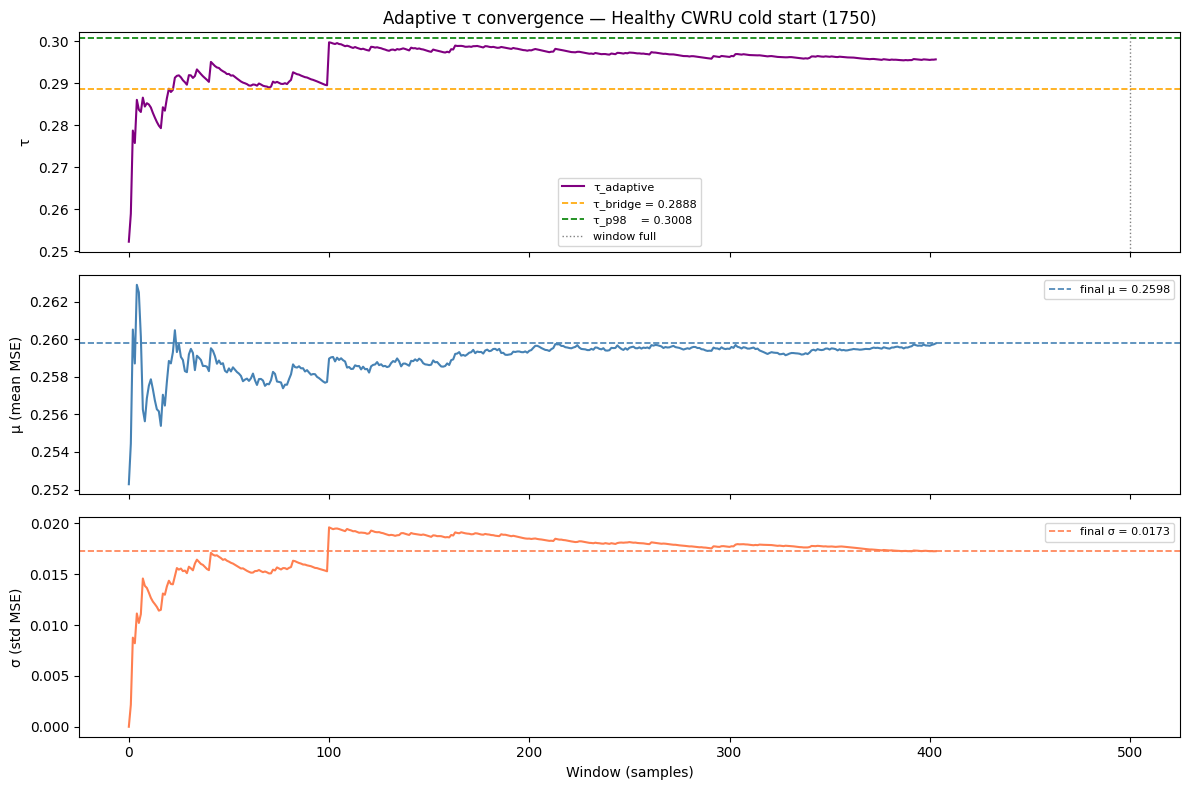

In [18]:
mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer, tau_mc, tau_bridge, tau_campo_p98, tau_t = run_experiment(bearing_id="1750")
mu_cwru  = mse_cwru_healthy.mean()
std_cwru = mse_cwru_healthy.std()

plot_experiment("1750", mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer, tau_mc, tau_bridge, tau_campo_p98, tau_t)

#### 1772 ####

Normal: (483903, 1)
Ball:   (486598, 1)
Inner:  (486744, 1)
Outer:  (854807, 1)
τ_MC = 0.094570  (z_mc = 1.679)
Windows → healthy:403 ball:405 inner:405 outer:712
Campo    → mu=0.2671, std=0.0217
τ_bridge = 0.3035
τ_campo p98 = 0.3209

τ_adaptativo (tras warm-up) = 0.3035
  mu_t=0.2671, sigma_t=0.0217

── Detection rates (MSE > τ) ──────────────────────────────
Régimen          τ_MC   τ_bridge   τ_p98_campo    τ_adapt
-------------------------------------------------------
Healthy        100.0%       5.5%          2.2%       5.5%
Ball           100.0%     100.0%         99.8%     100.0%
Inner          100.0%     100.0%        100.0%     100.0%
Outer          100.0%     100.0%         99.9%     100.0%


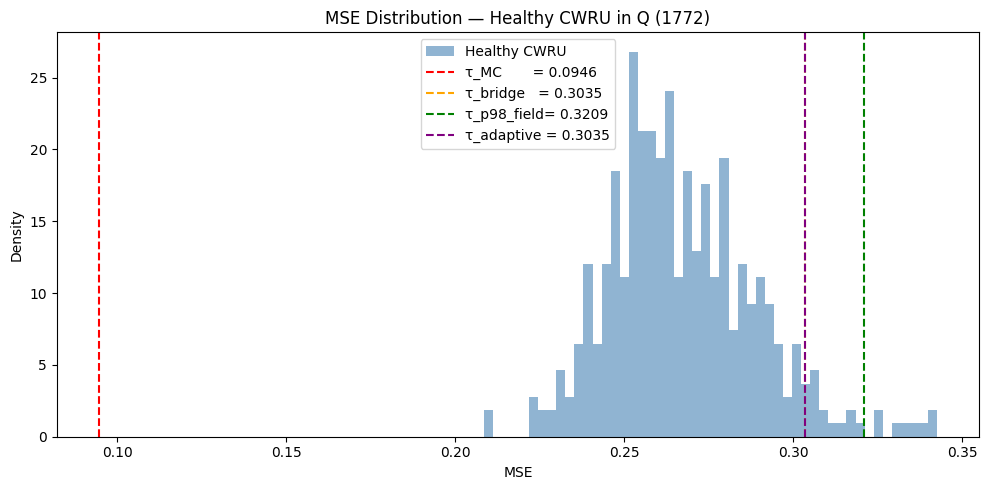

Healthy CWRU → mean=0.2671, std=0.0217, p98=0.3209, p99=0.3332


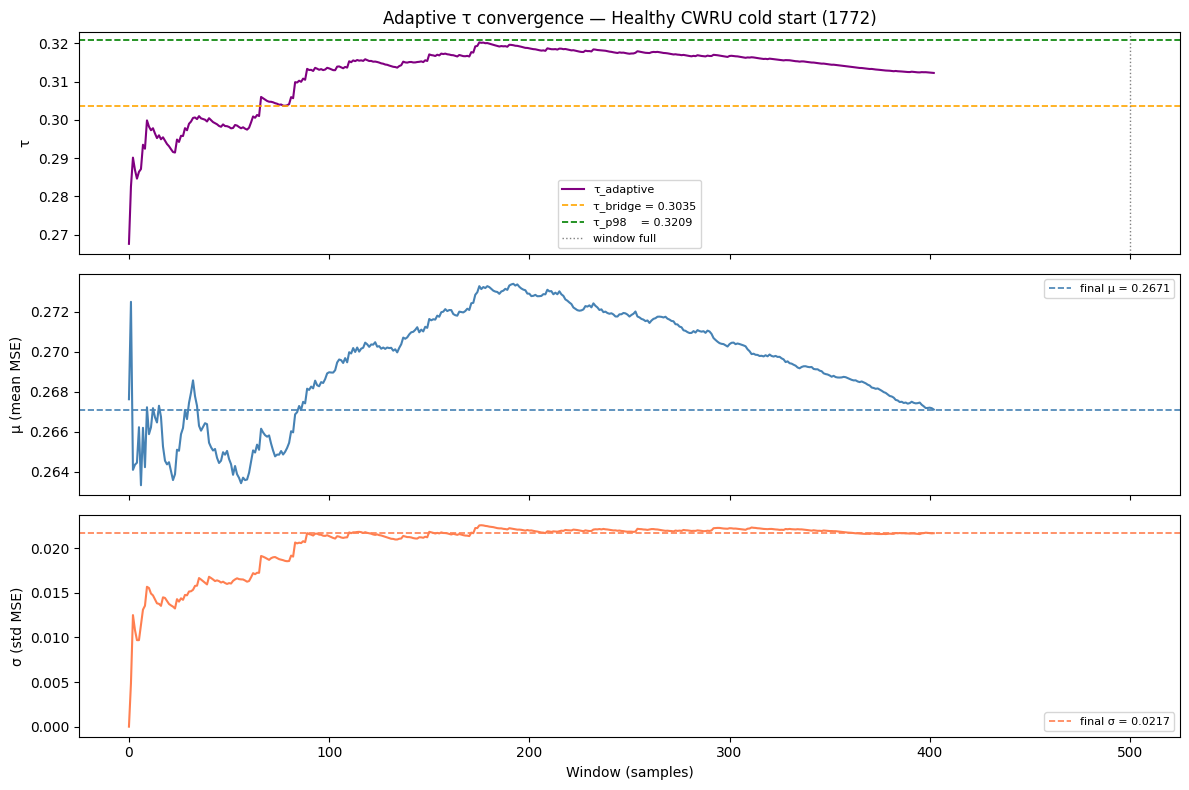

In [19]:
mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer, tau_mc, tau_bridge, tau_campo_p98, tau_t = run_experiment(bearing_id="1772")
mu_cwru  = mse_cwru_healthy.mean()
std_cwru = mse_cwru_healthy.std()

plot_experiment("1772", mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer, tau_mc, tau_bridge, tau_campo_p98, tau_t)

#### 1797 

Normal: (243938, 1)
Ball:   (487209, 1)
Inner:  (486048, 1)
Outer:  (854372, 1)
τ_MC = 0.094570  (z_mc = 1.679)
Windows → healthy:203 ball:406 inner:405 outer:711
Campo    → mu=0.2943, std=0.0222
τ_bridge = 0.3315
τ_campo p98 = 0.3443

τ_adaptativo (tras warm-up) = 0.3315
  mu_t=0.2943, sigma_t=0.0222

── Detection rates (MSE > τ) ──────────────────────────────
Régimen          τ_MC   τ_bridge   τ_p98_campo    τ_adapt
-------------------------------------------------------
Healthy        100.0%       4.4%          2.5%       4.4%
Ball           100.0%      97.5%         96.8%      97.5%
Inner          100.0%     100.0%        100.0%     100.0%
Outer          100.0%     100.0%        100.0%     100.0%


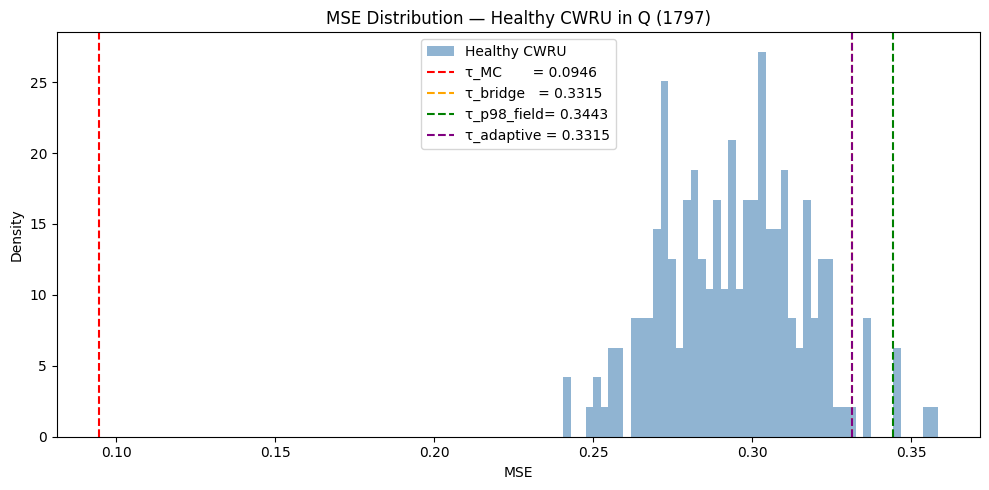

Healthy CWRU → mean=0.2943, std=0.0222, p98=0.3443, p99=0.3455


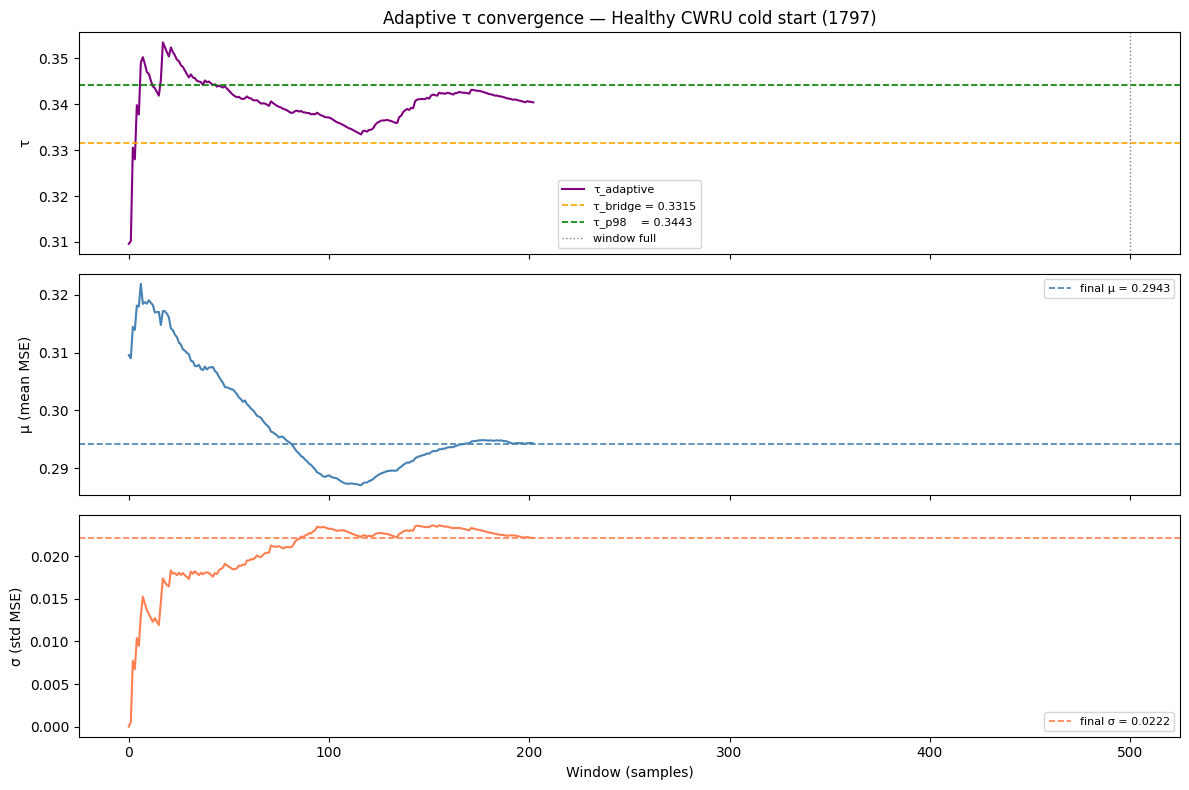

In [20]:
mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer, tau_mc, tau_bridge, tau_campo_p98, tau_t = run_experiment(bearing_id="1797")
mu_cwru  = mse_cwru_healthy.mean()
std_cwru = mse_cwru_healthy.std()

plot_experiment("1797", mse_cwru_healthy, mse_cwru_ball, mse_cwru_inner, mse_cwru_outer, tau_mc, tau_bridge, tau_campo_p98, tau_t)